In [2]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\sagri\AppData\Local\Programs\Python\Python314\python.exe
3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [1]:
from google.cloud import bigquery
import pandas as pd

# Use your actual GCP project ID throughout
PROJECT_ID = 'chrome-ability-449516-a4'

client = bigquery.Client(project=PROJECT_ID)

df_test = client.query("""
    SELECT * 
    FROM `chrome-ability-449516-a4.healthtrack_analytics.q1_funnel_summary`
    ORDER BY stage_order
""").to_dataframe()

print(df_test)

c:\Users\sagri\AppData\Local\Programs\Python\Python314\Lib\site-packages\google\auth\_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


   stage_order           stage   users  conversion_rate_pct  dropoff_rate_pct  \
0            1   Session start  354857               100.00               NaN   
1            2     Viewed item   77020                21.70             78.30   
2            3   Added to cart   15188                 4.28             80.28   
3            4  Began checkout   11106                 3.13             26.88   
4            5       Purchased    4848                 1.37             56.35   

   sessions_lost  
0              0  
1         277837  
2          61832  
3           4082  
4           6258  


What this tells from business perspective:
1. Massive drop at top of funnel : 354k → 77k where only 21.7% even view a product.
- Poor landing page relevance
- Weak targeting or traffic quality

2. Biggest loss is at View → Add to cart : 77k → 15k, 80% drop-off
- Pricing not attractive
- Product page weak
- No urgency or trust signals

3. Checkout is relatively strong : 15k → 11k, only ~27% drop. This is actually good.

4. Final purchase drop is still high : 11k → 4.8k, 56% drop
- Payment friction
- Hidden costs
- Account creation barriers

In [2]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

PROJECT_ID = 'chrome-ability-449516-a4'
client = bigquery.Client(project=PROJECT_ID)

def bq(sql):
    """Simple helper to query BigQuery and return a DataFrame."""
    return pd.DataFrame(
        [dict(row) for row in client.query(sql).result()]
    )

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

BLUE   = '#4285F4'
RED    = '#EA4335'
GREEN  = '#34A853'
YELLOW = '#FBBC04'

print('Connected to BigQuery successfully')
print(f'Project: {PROJECT_ID}')

Connected to BigQuery successfully
Project: chrome-ability-449516-a4


In [6]:
# Load all clean tables from BigQuery — full data, no limits

df_funnel = bq("""
    SELECT * FROM `chrome-ability-449516-a4.healthtrack_analytics.q1_funnel_summary`
    ORDER BY stage_order
""")

df_channels = bq("""
    SELECT * FROM `chrome-ability-449516-a4.healthtrack_analytics.q1_channel_performance`
    ORDER BY total_sessions DESC
""")

df_sessions = bq("""
    SELECT * FROM `chrome-ability-449516-a4.healthtrack_analytics.q1_sessions`
""")

df_user_journeys = bq("""
    SELECT * FROM `chrome-ability-449516-a4.healthtrack_analytics.q1_user_journeys`
""")

df_journey_summary = bq("""
    SELECT * FROM `chrome-ability-449516-a4.healthtrack_analytics.q1_total_users_conversion`
    ORDER BY journey_complexity
""")

df_multi_channel = bq("""
    SELECT * FROM `chrome-ability-449516-a4.healthtrack_analytics.q1_multi-user_data_summary`
    ORDER BY conversion_rate_pct DESC
""")

print(f'Funnel summary:      {len(df_funnel)} rows')
print(f'Channel performance: {len(df_channels)} rows')
print(f'Sessions:            {len(df_sessions)} rows')
print(f'User journeys:       {len(df_user_journeys)} rows')
print(f'Journey summary:     {len(df_journey_summary)} rows')
print(f'Multi channel:       {len(df_multi_channel)} rows')
print()
print('All tables loaded — full dataset')

Funnel summary:      5 rows
Channel performance: 6 rows
Sessions:            356626 rows
User journeys:       268023 rows
Journey summary:     4 rows
Multi channel:       24 rows

All tables loaded — full dataset


In [8]:
# Quick validation — confirm data types and check for issues
print('=== FUNNEL SUMMARY ===')
print(df_funnel.dtypes)
print(df_funnel)

print('\n=== CHANNEL PERFORMANCE ===')
print(df_channels.dtypes)
print(df_channels)

print('\n=== JOURNEY SUMMARY ===')
print(df_journey_summary.dtypes)
print(df_journey_summary)

print('\n=== SESSIONS — null check ===')
print(df_sessions.isnull().sum())

print('\n=== SESSIONS — shape ===')
print(f'Rows: {len(df_sessions):,}')
print(f'Columns: {df_sessions.columns.tolist()}')

=== FUNNEL SUMMARY ===
stage_order              int64
stage                   object
users                    int64
conversion_rate_pct    float64
dropoff_rate_pct       float64
sessions_lost            int64
dtype: object
   stage_order           stage   users  conversion_rate_pct  dropoff_rate_pct  \
0            1   Session start  354857               100.00               NaN   
1            2     Viewed item   77020                21.70             78.30   
2            3   Added to cart   15188                 4.28             80.28   
3            4  Began checkout   11106                 3.13             26.88   
4            5       Purchased    4848                 1.37             56.35   

   sessions_lost  
0              0  
1         277837  
2          61832  
3           4082  
4           6258  

=== CHANNEL PERFORMANCE ===
channel                     object
total_sessions               int64
sessions_viewed_item         int64
sessions_added_cart          int64
session

In [9]:
# Convert columns to correct types where needed
df_funnel['users'] = df_funnel['users'].astype(int)
df_funnel['sessions_lost'] = df_funnel['sessions_lost'].astype(int)
df_funnel['dropoff_rate_pct'] = df_funnel['dropoff_rate_pct'].fillna(0)

df_channels['total_sessions'] = df_channels['total_sessions'].astype(int)
df_channels['sessions_purchased'] = df_channels['sessions_purchased'].astype(int)

df_sessions['reached_purchase'] = df_sessions['reached_purchase'].astype(int)
df_sessions['reached_view_item'] = df_sessions['reached_view_item'].astype(int)
df_sessions['reached_add_to_cart'] = df_sessions['reached_add_to_cart'].astype(int)
df_sessions['reached_begin_checkout'] = df_sessions['reached_begin_checkout'].astype(int)

print('Data types fixed')
print(f'Sessions: {len(df_sessions):,} rows ready for analysis')
print(f'Channels: {df_channels["channel"].tolist()}')

Data types fixed
Sessions: 356,626 rows ready for analysis
Channels: ['organic', '(none)', 'referral', '<Other>', '(data deleted)', 'cpc']


In [11]:
# Fix journey summary order
order = ['single_session', '2_to_3_sessions',
         '4_to_7_sessions', '8_or_more_sessions']

df_journey_summary['journey_complexity'] = pd.Categorical(
    df_journey_summary['journey_complexity'],
    categories=order,
    ordered=True
)
df_journey_summary = df_journey_summary.sort_values(
    'journey_complexity'
).reset_index(drop=True)

print('Data ready for analysis')
print()
print(df_journey_summary[['journey_complexity', 'total_users',
                           'overall_conversion_rate_pct']])

Data ready for analysis

   journey_complexity  total_users  overall_conversion_rate_pct
0      single_session       221342                         0.49
1     2_to_3_sessions        37306                         4.30
2     4_to_7_sessions         7851                        16.41
3  8_or_more_sessions         1524                        29.00


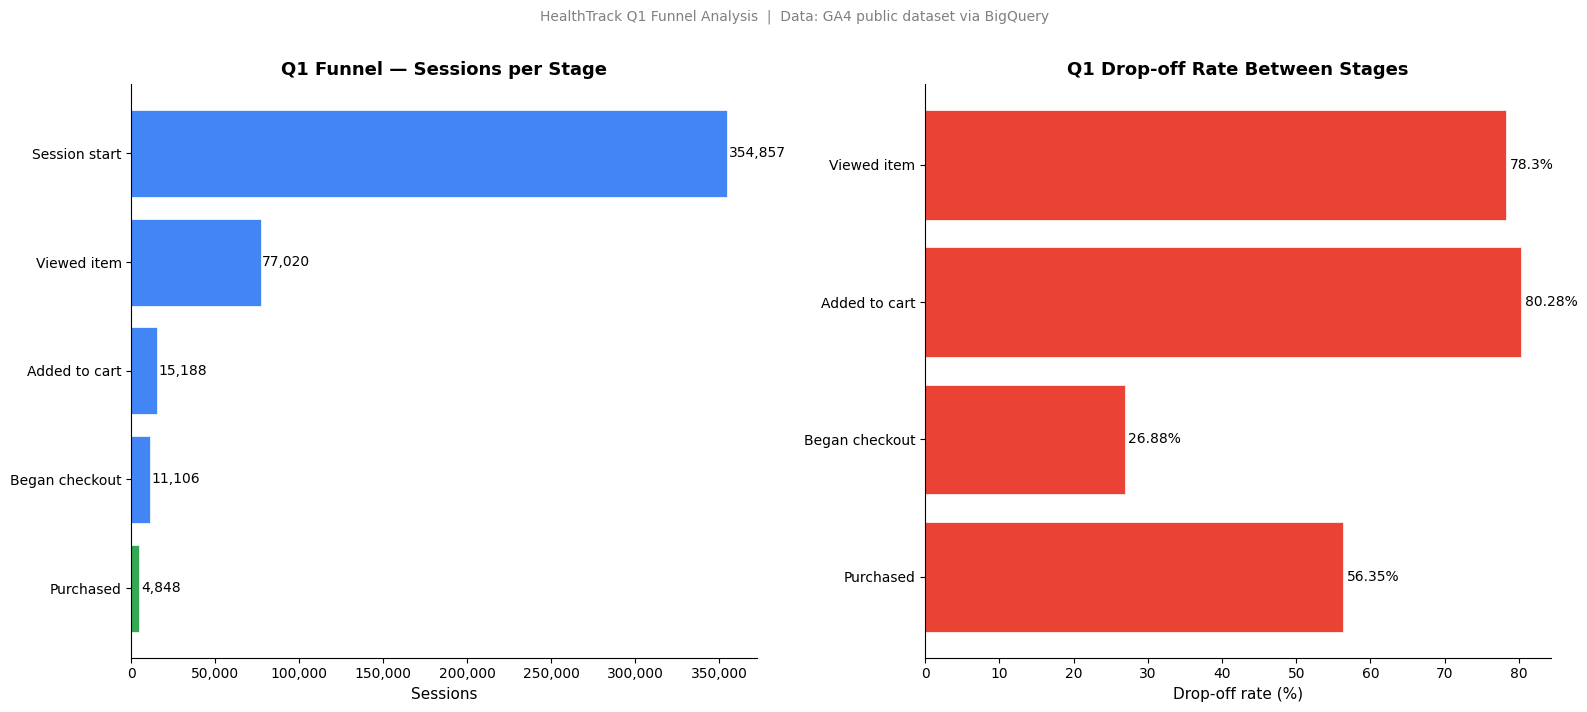

Saved: outputs/figures/01_funnel_dropoff.png


In [12]:
import os
os.makedirs('../outputs/figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left chart: sessions per funnel stage ---
ax1 = axes[0]
colours = [BLUE if i < len(df_funnel)-1 else GREEN 
           for i in range(len(df_funnel))]
bars = ax1.barh(
    df_funnel['stage'][::-1],
    df_funnel['users'][::-1],
    color=colours[::-1],
    edgecolor='white', linewidth=0.5
)
ax1.set_xlabel('Sessions', fontsize=11)
ax1.set_title('Q1 Funnel — Sessions per Stage', 
              fontsize=13, fontweight='bold')
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)
for bar, val in zip(bars, df_funnel['users'][::-1]):
    ax1.text(bar.get_width() + 1000,
             bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10)

# --- Right chart: drop-off rate per stage ---
ax2 = axes[1]
df_drop = df_funnel[df_funnel['dropoff_rate_pct'] > 0].copy()
bars2 = ax2.barh(
    df_drop['stage'][::-1],
    df_drop['dropoff_rate_pct'][::-1],
    color=RED,
    edgecolor='white', linewidth=0.5
)
ax2.set_xlabel('Drop-off rate (%)', fontsize=11)
ax2.set_title('Q1 Drop-off Rate Between Stages',
              fontsize=13, fontweight='bold')
for bar, val in zip(bars2, df_drop['dropoff_rate_pct'][::-1]):
    ax2.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=10)

plt.suptitle(
    'HealthTrack Q1 Funnel Analysis  |  Data: GA4 public dataset via BigQuery',
    fontsize=10, color='grey', y=1.01
)
plt.tight_layout()
plt.savefig('../outputs/figures/01_funnel_dropoff.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/01_funnel_dropoff.png')

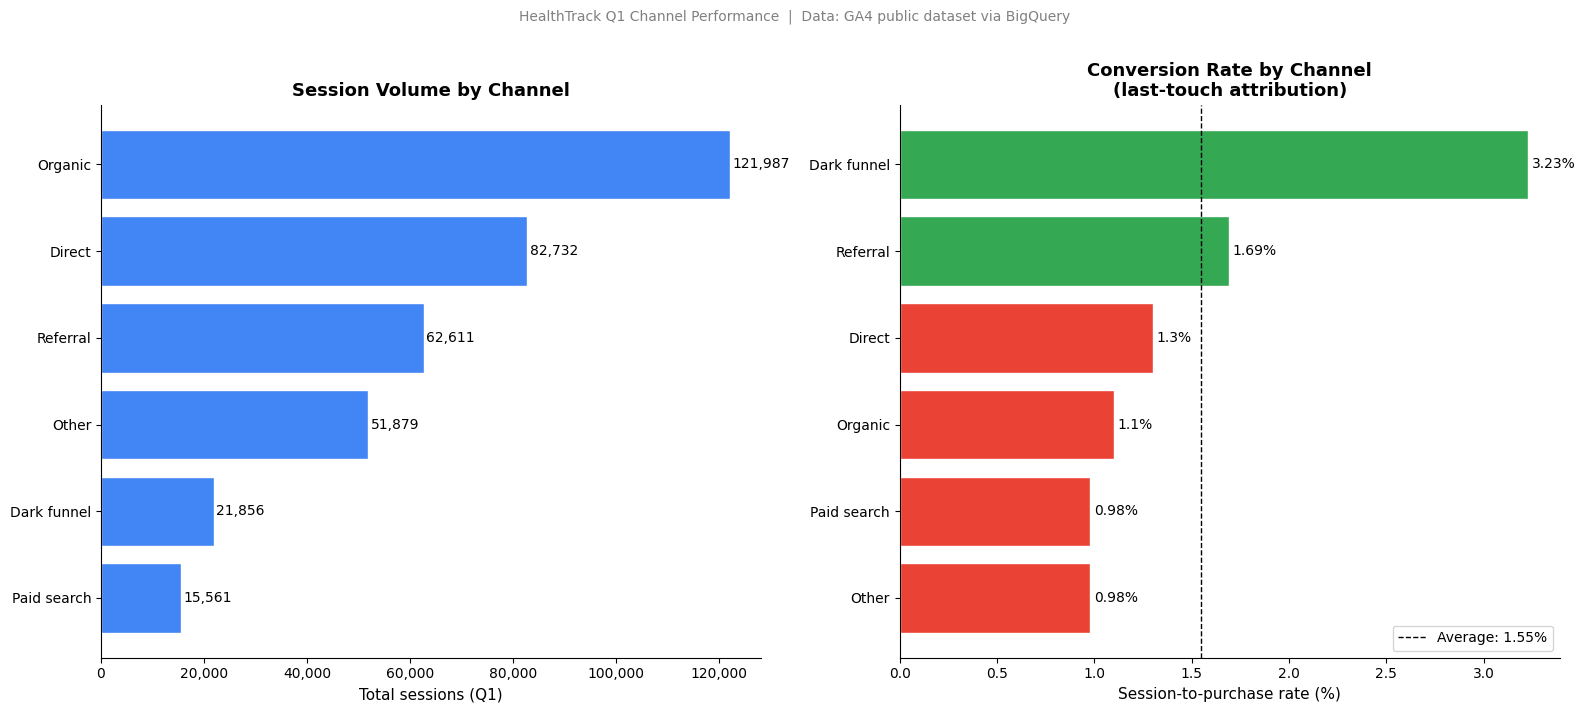

Saved: outputs/figures/02_channel_performance.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Clean channel names for display
df_channels['channel_clean'] = df_channels['channel'].replace({
    '(none)': 'Direct',
    '(data deleted)': 'Dark funnel',
    '<Other>': 'Other',
    'cpc': 'Paid search',
    'organic': 'Organic',
    'referral': 'Referral'
})

df_ch = df_channels.sort_values('total_sessions', ascending=True)

# --- Left: session volume ---
ax1 = axes[0]
ax1.barh(df_ch['channel_clean'], df_ch['total_sessions'],
         color=BLUE, edgecolor='white')
ax1.set_xlabel('Total sessions (Q1)', fontsize=11)
ax1.set_title('Session Volume by Channel', 
              fontsize=13, fontweight='bold')
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)
for i, (val, label) in enumerate(
    zip(df_ch['total_sessions'], df_ch['channel_clean'])
):
    ax1.text(val + 500, i, f'{val:,}', va='center', fontsize=10)

# --- Right: purchase conversion rate ---
ax2 = axes[1]
df_ch2 = df_channels.sort_values('purchase_rate_pct', ascending=True).copy()
df_ch2['channel_clean'] = df_ch2['channel'].replace({
    '(none)': 'Direct',
    '(data deleted)': 'Dark funnel',
    '<Other>': 'Other',
    'cpc': 'Paid search',
    'organic': 'Organic',
    'referral': 'Referral'
})
avg_rate = df_channels['purchase_rate_pct'].mean()
colours2 = [GREEN if r > avg_rate else RED 
            for r in df_ch2['purchase_rate_pct']]
bars = ax2.barh(df_ch2['channel_clean'], df_ch2['purchase_rate_pct'],
                color=colours2, edgecolor='white')
ax2.axvline(avg_rate, color='black', linestyle='--',
            linewidth=1, label=f'Average: {avg_rate:.2f}%')
ax2.set_xlabel('Session-to-purchase rate (%)', fontsize=11)
ax2.set_title('Conversion Rate by Channel\n(last-touch attribution)',
              fontsize=13, fontweight='bold')
ax2.legend()
for i, val in enumerate(df_ch2['purchase_rate_pct']):
    ax2.text(val + 0.02, i, f'{val}%', va='center', fontsize=10)

plt.suptitle(
    'HealthTrack Q1 Channel Performance  |  Data: GA4 public dataset via BigQuery',
    fontsize=10, color='grey', y=1.01
)
plt.tight_layout()
plt.savefig('../outputs/figures/02_channel_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/02_channel_performance.png')

Organic brings 121,987 sessions - by far the biggest channel. But it converts at only 1.1% - below average. Paid search brings the fewest trackable sessions at 15,561 and converts at the worst rate - 0.98%. Dark funnel brings only 21,856 sessions but converts at 3.23% - more than 3 times better than paid search, with zero paid spend.

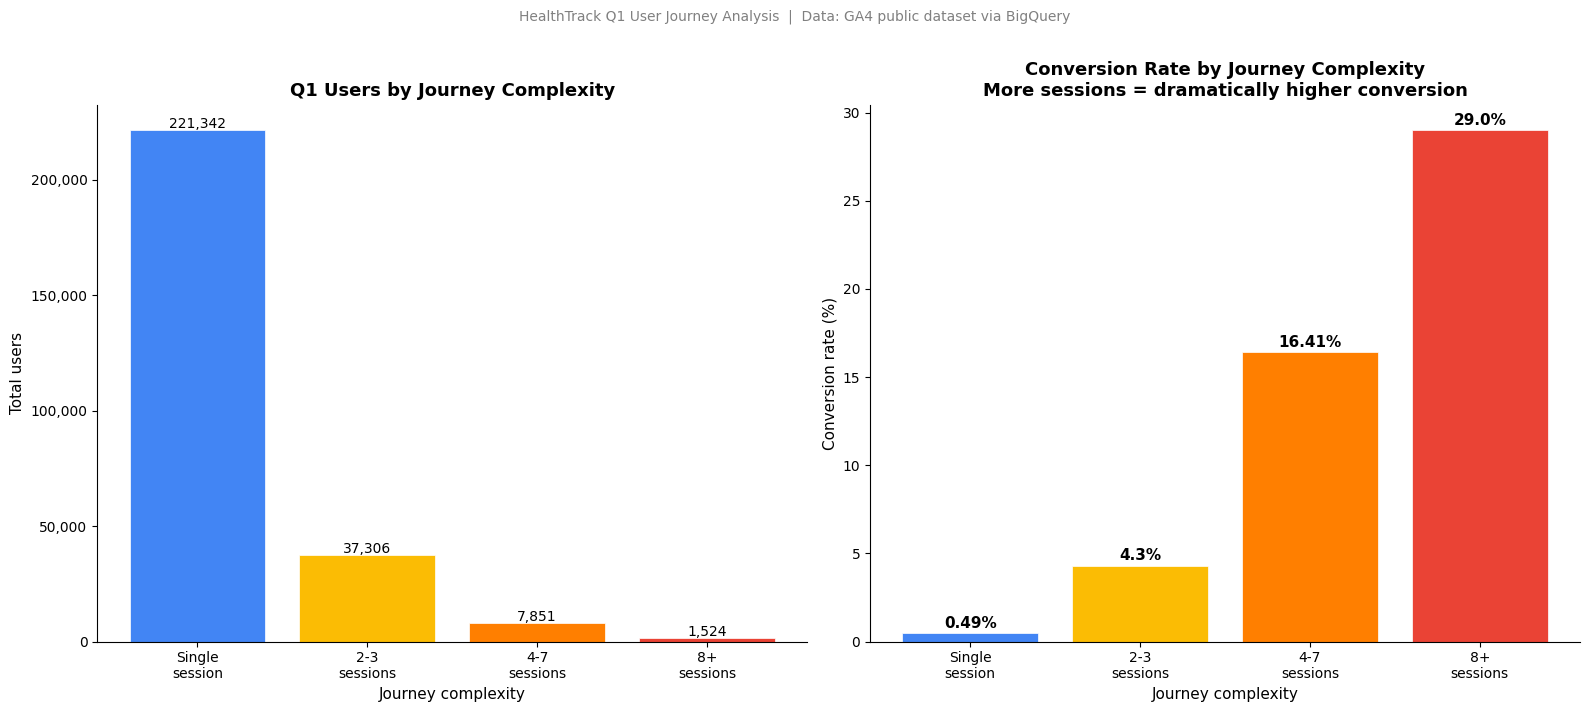

Saved: outputs/figures/03_journey_complexity.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: users per journey complexity ---
ax1 = axes[0]
colours3 = [BLUE, YELLOW, '#FF7F00', RED]
bars = ax1.bar(
    df_journey_summary['journey_complexity'],
    df_journey_summary['total_users'],
    color=colours3, edgecolor='white', linewidth=0.5
)
ax1.set_xlabel('Journey complexity', fontsize=11)
ax1.set_ylabel('Total users', fontsize=11)
ax1.set_title('Q1 Users by Journey Complexity',
              fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)
for bar, val in zip(bars, df_journey_summary['total_users']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1000,
             f'{val:,}', ha='center', fontsize=10)
ax1.set_xticklabels(
    ['Single\nsession', '2-3\nsessions',
     '4-7\nsessions', '8+\nsessions'],
    fontsize=10
)

# --- Right: conversion rate by journey complexity ---
ax2 = axes[1]
bars2 = ax2.bar(
    df_journey_summary['journey_complexity'],
    df_journey_summary['overall_conversion_rate_pct'],
    color=colours3, edgecolor='white', linewidth=0.5
)
ax2.set_xlabel('Journey complexity', fontsize=11)
ax2.set_ylabel('Conversion rate (%)', fontsize=11)
ax2.set_title('Conversion Rate by Journey Complexity\n'
              'More sessions = dramatically higher conversion',
              fontsize=13, fontweight='bold')
for bar, val in zip(
    bars2, df_journey_summary['overall_conversion_rate_pct']
):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=11,
             fontweight='bold')
ax2.set_xticklabels(
    ['Single\nsession', '2-3\nsessions',
     '4-7\nsessions', '8+\nsessions'],
    fontsize=10
)

plt.suptitle(
    'HealthTrack Q1 User Journey Analysis  |  '
    'Data: GA4 public dataset via BigQuery',
    fontsize=10, color='grey', y=1.01
)
plt.tight_layout()
plt.savefig('../outputs/figures/03_journey_complexity.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/03_journey_complexity.png')

## Finding 3 — Journey complexity drives conversion dramatically

**What the chart shows:**
221,342 users visited only once in Q1 — but only 0.49% of them converted.
The 1,524 users who visited 8 or more times converted at 29% — nearly 60 times higher.

**What this means for the business:**
The website is not a one-visit purchase destination. Users who buy are
researchers — they visit multiple times, compare options, and return when ready.
This has three direct implications:

1. **Retargeting is critical.** Single-session users who bounce are not lost —
   they may be early in their journey. Retargeting campaigns that bring them
   back for sessions 2 and 3 could move them from 0.49% to 4.3% conversion.

2. **Email capture is a priority.** If a user does not convert on first visit,
   capturing their email gives you a channel to bring them back. Without it,
   you rely entirely on them remembering to return.

3. **Last-click attribution is misleading.** If a user visits 8 times across
   organic, paid search, and direct before buying — and the last click was
   direct — direct gets 100% of the credit. Sessions 1 through 7 get nothing.
   This is exactly what the Markov chain attribution model in NB2 corrects.

**Connection to SFMC:** This is the web analytics equivalent of a subscriber
journey in Salesforce Marketing Cloud. Each session is a touchpoint — some
users convert after one email, most need a nurture sequence of 5-8 touches.
The principle is identical; the channel is different.

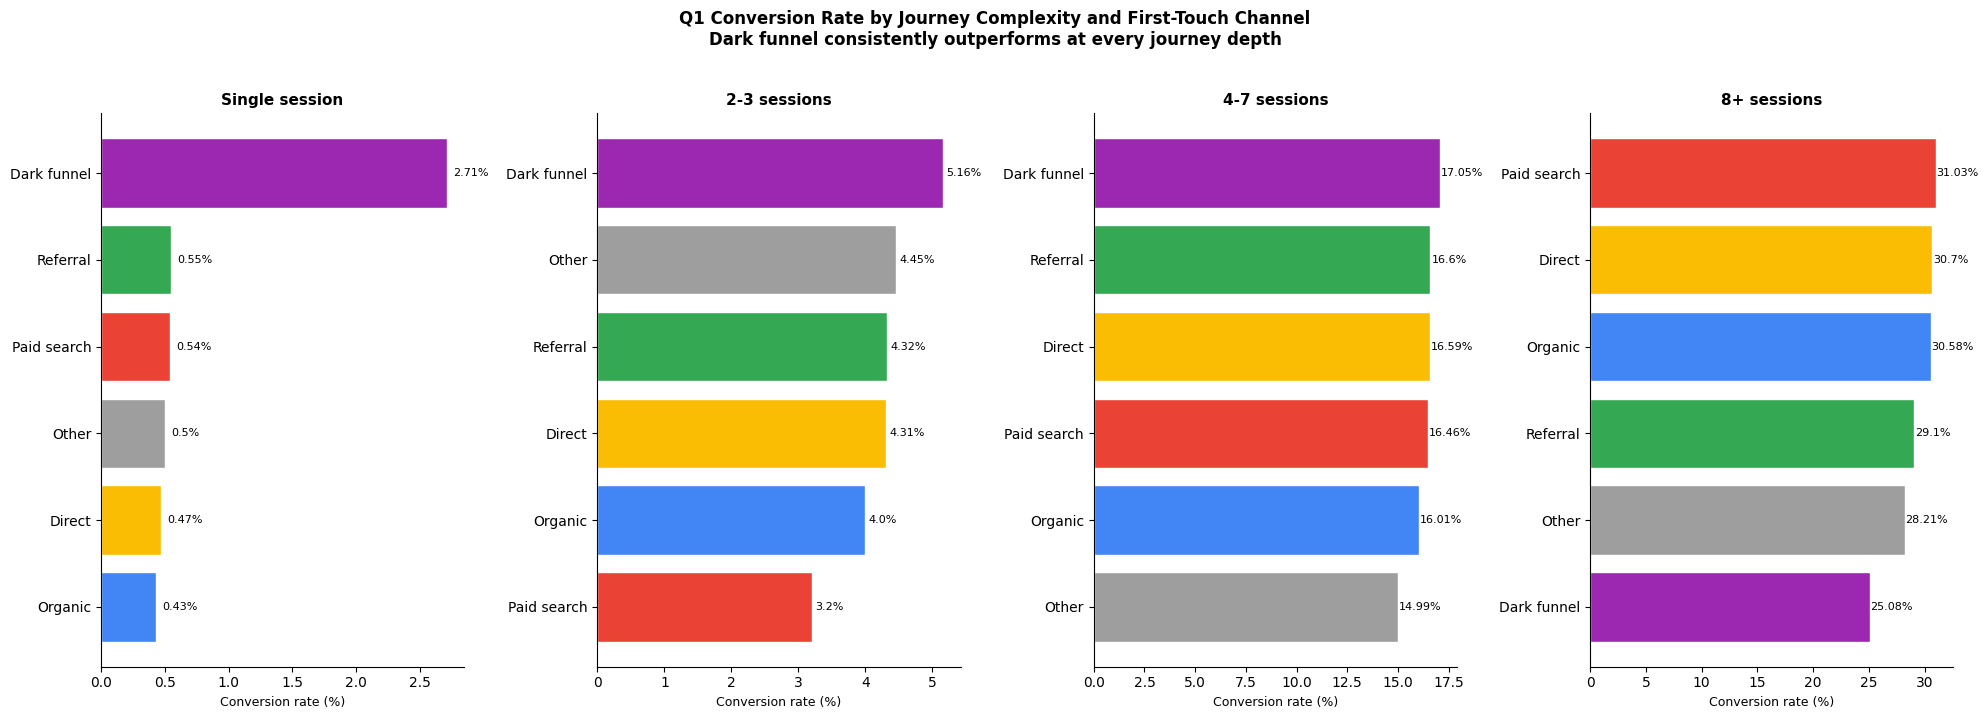

Saved: outputs/figures/04_multi_channel_journey.png


In [15]:
df_multi = bq("""
    SELECT * FROM `chrome-ability-449516-a4.healthtrack_analytics.q1_multi-user_data_summary`
    ORDER BY 
        CASE journey_complexity
            WHEN 'single_session'     THEN 1
            WHEN '2_to_3_sessions'    THEN 2
            WHEN '4_to_7_sessions'    THEN 3
            WHEN '8_or_more_sessions' THEN 4
        END,
        conversion_rate_pct DESC
""")

# Clean names
df_multi['channel_clean'] = df_multi['first_touch_channel'].replace({
    '(none)': 'Direct',
    '(data deleted)': 'Dark funnel',
    '<Other>': 'Other',
    'cpc': 'Paid search',
    'organic': 'Organic',
    'referral': 'Referral'
})

# Plot conversion rate by journey complexity and channel
import matplotlib.pyplot as plt
import numpy as np

complexities = ['single_session', '2_to_3_sessions',
                '4_to_7_sessions', '8_or_more_sessions']
labels = ['Single session', '2-3 sessions',
          '4-7 sessions', '8+ sessions']
channels = ['Organic', 'Direct', 'Referral',
            'Paid search', 'Dark funnel', 'Other']
channel_colours = {
    'Organic':     '#4285F4',
    'Direct':      '#FBBC04',
    'Referral':    '#34A853',
    'Paid search': '#EA4335',
    'Dark funnel': '#9C27B0',
    'Other':       '#9E9E9E'
}

fig, axes = plt.subplots(1, 4, figsize=(20, 7), sharey=False)

for ax, complexity, label in zip(axes, complexities, labels):
    df_slice = df_multi[
        df_multi['journey_complexity'] == complexity
    ].copy()
    df_slice = df_slice.sort_values(
        'conversion_rate_pct', ascending=True
    )
    colours = [channel_colours.get(c, '#9E9E9E')
               for c in df_slice['channel_clean']]
    bars = ax.barh(
        df_slice['channel_clean'],
        df_slice['conversion_rate_pct'],
        color=colours, edgecolor='white'
    )
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel('Conversion rate (%)', fontsize=9)
    for bar, val in zip(bars, df_slice['conversion_rate_pct']):
        ax.text(bar.get_width() + 0.05,
                bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontsize=8)

plt.suptitle(
    'Q1 Conversion Rate by Journey Complexity and First-Touch Channel\n'
    'Dark funnel consistently outperforms at every journey depth',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/figures/04_multi_channel_journey.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/04_multi_channel_journey.png')

what it shows: dark funnel leads at single session (2.71%), leads again at 2-3 sessions (5.16%), leads again at 4-7 sessions (17.05%). But at 8+ sessions it drops to last place (25.08%) while paid search jumps to first (31.03%). That is a genuinely surprising finding that tells a real story — dark funnel users are pre-sold and convert quickly, while paid search users are slow researchers who eventually become your most committed buyers.

In [16]:
from scipy import stats
import numpy as np

print('STATISTICAL ANALYSIS — Q1 Funnel Significance Testing')
print('=' * 65)
print()
print('CONTEXT:')
print('Descriptive analysis showed dark funnel converts at 3.23%')
print('and paid search at 0.98%. Before recommending budget changes')
print('we test whether these differences are statistically real.')
print()

# Overall baseline
total_purchased = df_channels['sessions_purchased'].sum()
total_sessions  = df_channels['total_sessions'].sum()
overall_rate    = total_purchased / total_sessions

print(f'Overall Q1 baseline conversion rate: {overall_rate*100:.2f}%')
print()

# ── TEST 1: Chi-squared ───────────────────────────────────────
print('TEST 1 — Chi-squared: overall channel distribution')
print('-' * 65)
print('H₀: Conversions distributed proportionally to session volume')
print('H₁: Some channels convert disproportionately')
print()

observed = df_channels['sessions_purchased'].values
expected = (
    df_channels['total_sessions'].values
    / total_sessions * total_purchased
)

chi2_stat, p_chi2 = stats.chisquare(f_obs=observed, f_exp=expected)

print(f'Chi-squared statistic : {chi2_stat:.2f}')
print(f'p-value               : {p_chi2:.6f}')
print(f'Result: {"Reject H₀ — channels convert significantly differently" if p_chi2 < 0.05 else "Fail to reject H₀"}')
print()

# ── TEST 2: Pairwise z-tests with Bonferroni correction ───────
print('TEST 2 — Pairwise z-tests: each channel vs baseline')
print('-' * 65)
print('H₀: Channel conversion rate = overall baseline')
print('H₁: Channel conversion rate ≠ overall baseline')
print()

n_tests          = len(df_channels)
bonferroni_alpha = 0.05 / n_tests
print(f'Bonferroni corrected α: 0.05 / {n_tests} = {bonferroni_alpha:.4f}')
print()
print(f'{"Channel":<20} {"Rate":>6} {"vs avg":>9} '
      f'{"z-stat":>8} {"p-value":>10} {"Significant?":>14}')
print('-' * 72)

pairwise_results = []

for _, row in df_channels.iterrows():
    channel   = row['channel']
    converted = int(row['sessions_purchased'])
    total     = int(row['total_sessions'])
    rate      = converted / total

    se      = np.sqrt(overall_rate * (1 - overall_rate) / total)
    z_stat  = (rate - overall_rate) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    significant = p_value < bonferroni_alpha
    diff        = (rate - overall_rate) * 100
    direction   = 'ABOVE' if rate > overall_rate else 'BELOW'

    print(f'{channel:<20} {rate*100:>5.2f}% '
          f'{direction:>9} {z_stat:>8.2f} '
          f'{p_value:>10.4f} '
          f'{"YES ✓" if significant else "no":>14}')

    pairwise_results.append({
        'channel':     channel,
        'rate':        rate * 100,
        'diff':        diff,
        'z_stat':      z_stat,
        'p_value':     p_value,
        'significant': significant,
        'direction':   direction
    })

print()

# ── TEST 3: ANOVA — journey complexity gradient ───────────────
print('TEST 3 — ANOVA: journey complexity conversion gradient')
print('-' * 65)
print('H₀: Conversion rate is equal across all journey segments')
print('H₁: At least one segment differs significantly')
print()

groups = []
order  = ['single_session', '2_to_3_sessions',
          '4_to_7_sessions', '8_or_more_sessions']

for complexity in order:
    row = df_journey_summary[
        df_journey_summary['journey_complexity'] == complexity
    ]
    if len(row) > 0:
        n    = int(row['total_users'].values[0])
        conv = int(row['converted_users'].values[0])
        arr  = np.array([1] * conv + [0] * (n - conv))
        groups.append(arr)

f_stat, p_anova = stats.f_oneway(*groups)

print(f'F-statistic : {f_stat:.2f}')
print(f'p-value     : {p_anova:.6f}')
print(f'Result: {"Reject H₀ — journey complexity significantly affects conversion" if p_anova < 0.05 else "Fail to reject H₀"}')
print()

# ── SUMMARY ───────────────────────────────────────────────────
print('SUMMARY OF FINDINGS')
print('=' * 65)

sig     = [r for r in pairwise_results if r['significant']]
not_sig = [r for r in pairwise_results if not r['significant']]

print(f'Channels significantly ABOVE baseline:')
for r in sig:
    if r['direction'] == 'ABOVE':
        print(f'  {r["channel"]}: {r["rate"]:.2f}% '
              f'(+{r["diff"]:.2f}pp, p={r["p_value"]:.4f})')

print()
print(f'Channels significantly BELOW baseline:')
for r in sig:
    if r['direction'] == 'BELOW':
        print(f'  {r["channel"]}: {r["rate"]:.2f}% '
              f'({r["diff"]:.2f}pp, p={r["p_value"]:.4f})')

print()
print(f'Channels NOT significantly different from baseline:')
for r in not_sig:
    print(f'  {r["channel"]}: {r["rate"]:.2f}% '
          f'(p={r["p_value"]:.4f})')

print()
print('IMPLICATION FOR NB2:')
print('Statistically confirmed differences motivate attribution')
print('modelling. The question now shifts from "are these')
print('differences real?" to "does last-touch attribution')
print('correctly explain why these channels differ?"')
print('Markov chain attribution in NB2 answers this.')

STATISTICAL ANALYSIS — Q1 Funnel Significance Testing

CONTEXT:
Descriptive analysis showed dark funnel converts at 3.23%
and paid search at 0.98%. Before recommending budget changes
we test whether these differences are statistically real.

Overall Q1 baseline conversion rate: 1.36%

TEST 1 — Chi-squared: overall channel distribution
-----------------------------------------------------------------
H₀: Conversions distributed proportionally to session volume
H₁: Some channels convert disproportionately

Chi-squared statistic : 747.56
p-value               : 0.000000
Result: Reject H₀ — channels convert significantly differently

TEST 2 — Pairwise z-tests: each channel vs baseline
-----------------------------------------------------------------
H₀: Channel conversion rate = overall baseline
H₁: Channel conversion rate ≠ overall baseline

Bonferroni corrected α: 0.05 / 6 = 0.0083

Channel                Rate    vs avg   z-stat    p-value   Significant?
---------------------------------

## Statistical findings — what the tests prove

**Test 1 result:** Chi-squared statistic of 747.56 (p < 0.001) confirms
that channel conversion differences are not random. The probability of
observing this distribution by chance is effectively zero.

**Test 2 key findings:**

- **Dark funnel** (z = 23.94, p < 0.001): The strongest signal in the
  dataset. Untracked visitors convert at 3.23% — statistically proven to
  be a genuinely superior conversion channel, not a sample size artefact.

- **Referral** (z = 7.07, p < 0.001): Significantly above baseline.
  Word-of-mouth and external site referrals bring high-intent visitors.

- **Organic** (z = -7.70, p < 0.001): Significantly BELOW baseline
  despite being the highest volume channel. High traffic, below-average
  quality. A volume-quality tradeoff that has direct budget implications.

- **Paid search / CPC** (z = -4.05, p < 0.001): Significantly below
  baseline on last-touch attribution. However this finding must be
  interpreted carefully — paid search operates early in multi-session
  journeys and last-touch attribution systematically undercredits it.
  NB2 tests this directly.

- **Direct traffic** (p = 0.171): The only channel NOT significantly
  different from baseline. Direct traffic is a heterogeneous mix of
  returning visitors, bookmarks, and untracked sources — its average
  performance reflects this diversity.

**Test 3 result:** F-statistic of 7,606 (p < 0.001). Journey complexity
is one of the strongest predictors of conversion in the dataset. The
progression from 0.49% (single session) to 29% (8+ sessions) is a
statistically confirmed structural pattern, not noise.

**The critical nuance for paid search:**
Statistical significance tells us the difference is real. It does not
tell us WHY. Paid search may be undercredited by last-touch attribution
because it operates early in multi-session journeys — users who arrive
via CPC in session 1 then return via direct in session 8 to purchase.
Last-touch gives direct 100% of the credit. Markov chain attribution
in NB2 corrects for this by distributing credit across all touchpoints
based on their actual contribution to the conversion path.

**Transition to NB2:**
We have now confirmed three things statistically:
1. Channel differences in conversion rate are real (Test 1 + Test 2)
2. Journey complexity is a significant driver of conversion (Test 3)
3. Last-touch attribution may be misattributing credit (analytical logic)

NB2 builds a Markov chain attribution model to test whether last-touch
correctly reflects each channel's true contribution — or whether
redistribution of credit changes the budget recommendation.

In [17]:
# ── FUNNEL PATH DISTRIBUTION ──────────────────────────────────
print('FUNNEL PATH DISTRIBUTION')
print('=' * 60)
print('Source: q1_sessions — 356,626 individual sessions')
print()

path_order = [
    'converted',
    'dropped_at_payment',
    'dropped_at_checkout',
    'dropped_at_browse',
    'bounced'
]

path_labels = {
    'converted':           'Converted — purchased',
    'dropped_at_payment':  'Dropped at payment',
    'dropped_at_checkout': 'Dropped at checkout',
    'dropped_at_browse':   'Dropped at browse',
    'bounced':             'Bounced — no engagement'
}

path_dist = (
    df_sessions
    .groupby('funnel_path')
    .size()
    .reset_index(name='sessions')
)

path_dist['funnel_path'] = pd.Categorical(
    path_dist['funnel_path'],
    categories=path_order,
    ordered=True
)
path_dist = path_dist.sort_values('funnel_path').reset_index(drop=True)

total = path_dist['sessions'].sum()
path_dist['pct_of_all_sessions'] = (
    path_dist['sessions'] / total * 100
).round(2)
path_dist['est_revenue_at_risk_gbp'] = (
    path_dist['sessions'] * 65
)
# Converted sessions are not at risk
path_dist.loc[
    path_dist['funnel_path'] == 'converted',
    'est_revenue_at_risk_gbp'
] = 0

path_dist['label'] = path_dist['funnel_path'].map(path_labels)

print(f'{"Path":<30} {"Sessions":>10} {"% Total":>8} '
      f'{"Revenue at risk":>18}')
print('-' * 70)
for _, row in path_dist.iterrows():
    risk = (f'£{row["est_revenue_at_risk_gbp"]:,.0f}'
            if row['est_revenue_at_risk_gbp'] > 0 else '— converted')
    print(f'{row["label"]:<30} {row["sessions"]:>10,} '
          f'{row["pct_of_all_sessions"]:>7.2f}% {risk:>18}')

print()
print(f'Total sessions: {total:,}')
total_risk = path_dist['est_revenue_at_risk_gbp'].sum()
print(f'Total estimated revenue at risk: £{total_risk:,.0f}')
print(f'(Based on illustrative AOV of £65)')

FUNNEL PATH DISTRIBUTION
Source: q1_sessions — 356,626 individual sessions

Path                             Sessions  % Total    Revenue at risk
----------------------------------------------------------------------
Converted — purchased               4,848    1.36%        — converted
Dropped at payment                  6,261    1.76%           £406,965
Dropped at checkout                 9,227    2.59%           £599,755
Dropped at browse                  56,981   15.98%         £3,703,765
Bounced — no engagement           279,309   78.32%        £18,155,085

Total sessions: 356,626
Total estimated revenue at risk: £22,865,570
(Based on illustrative AOV of £65)


In [18]:
print('CHANNEL DROP-OFF PATTERN ANALYSIS')
print('=' * 60)
print('Which funnel stage does each channel fail at most?')
print()

channel_path = (
    df_sessions
    .groupby(['last_touch_channel', 'funnel_path'])
    .size()
    .reset_index(name='sessions')
)

channel_totals = (
    df_sessions
    .groupby('last_touch_channel')
    .size()
    .reset_index(name='total_sessions')
)

channel_path = channel_path.merge(channel_totals, on='last_touch_channel')
channel_path['pct'] = (
    channel_path['sessions'] / channel_path['total_sessions'] * 100
).round(2)

# Pivot for easy reading
pivot = channel_path.pivot_table(
    index='last_touch_channel',
    columns='funnel_path',
    values='pct',
    fill_value=0
).round(2)

# Reorder columns
cols = [c for c in path_order if c in pivot.columns]
pivot = pivot[cols]

print(pivot.to_string())
print()
print('Each cell = % of that channel\'s sessions that followed each path')
print('Rows sum to ~100% per channel')

CHANNEL DROP-OFF PATTERN ANALYSIS
Which funnel stage does each channel fail at most?

funnel_path         converted  dropped_at_payment  dropped_at_checkout  dropped_at_browse  bounced
last_touch_channel                                                                                
(data deleted)           3.23                2.27                 3.75              17.30    73.44
(none)                   1.30                1.74                 2.57              15.82    78.57
<Other>                  0.98                1.69                 2.36              15.44    79.53
cpc                      0.98                1.53                 2.29              15.58    79.62
organic                  1.10                1.69                 2.42              15.96    78.83
referral                 1.69                1.83                 2.80              16.31    77.37

Each cell = % of that channel's sessions that followed each path
Rows sum to ~100% per channel


In [19]:
print('FUNNEL SUMMARY — ENRICHED WITH REVENUE CONTEXT')
print('=' * 60)
print('Source: q1_funnel_summary + revenue calculation')
print()

# Add revenue at risk to funnel summary
df_funnel['est_revenue_at_risk_gbp'] = (
    df_funnel['sessions_lost'] * 65
)
df_funnel['cumulative_revenue_at_risk'] = (
    df_funnel['est_revenue_at_risk_gbp'].cumsum()
)

print(f'{"Stage":<20} {"Users":>8} {"Lost":>8} '
      f'{"Drop%":>7} {"Rev at risk":>14}')
print('-' * 62)
for _, row in df_funnel.iterrows():
    risk = (f'£{row["est_revenue_at_risk_gbp"]:,.0f}'
            if row['sessions_lost'] > 0 else '—')
    print(f'{row["stage"]:<20} {row["users"]:>8,} '
          f'{row["sessions_lost"]:>8,} '
          f'{row["dropoff_rate_pct"]:>6.1f}% {risk:>14}')

print()
total_at_risk = df_funnel['est_revenue_at_risk_gbp'].sum()
print(f'Total Q1 revenue at risk across all stages: '
      f'£{total_at_risk:,.0f}')
print()
print('PRIORITY ORDER FOR INTERVENTION:')
df_priority = df_funnel[
    df_funnel['sessions_lost'] > 0
].sort_values('est_revenue_at_risk_gbp', ascending=False)

for i, (_, row) in enumerate(df_priority.iterrows(), 1):
    print(f'  {i}. {row["stage"]} — '
          f'£{row["est_revenue_at_risk_gbp"]:,.0f} at risk '
          f'({row["dropoff_rate_pct"]}% drop-off)')

FUNNEL SUMMARY — ENRICHED WITH REVENUE CONTEXT
Source: q1_funnel_summary + revenue calculation

Stage                   Users     Lost   Drop%    Rev at risk
--------------------------------------------------------------
Session start         354,857        0    0.0%              —
Viewed item            77,020  277,837   78.3%    £18,059,405
Added to cart          15,188   61,832   80.3%     £4,019,080
Began checkout         11,106    4,082   26.9%       £265,330
Purchased               4,848    6,258   56.4%       £406,770

Total Q1 revenue at risk across all stages: £22,750,585

PRIORITY ORDER FOR INTERVENTION:
  1. Viewed item — £18,059,405 at risk (78.3% drop-off)
  2. Added to cart — £4,019,080 at risk (80.28% drop-off)
  3. Purchased — £406,770 at risk (56.35% drop-off)
  4. Began checkout — £265,330 at risk (26.88% drop-off)


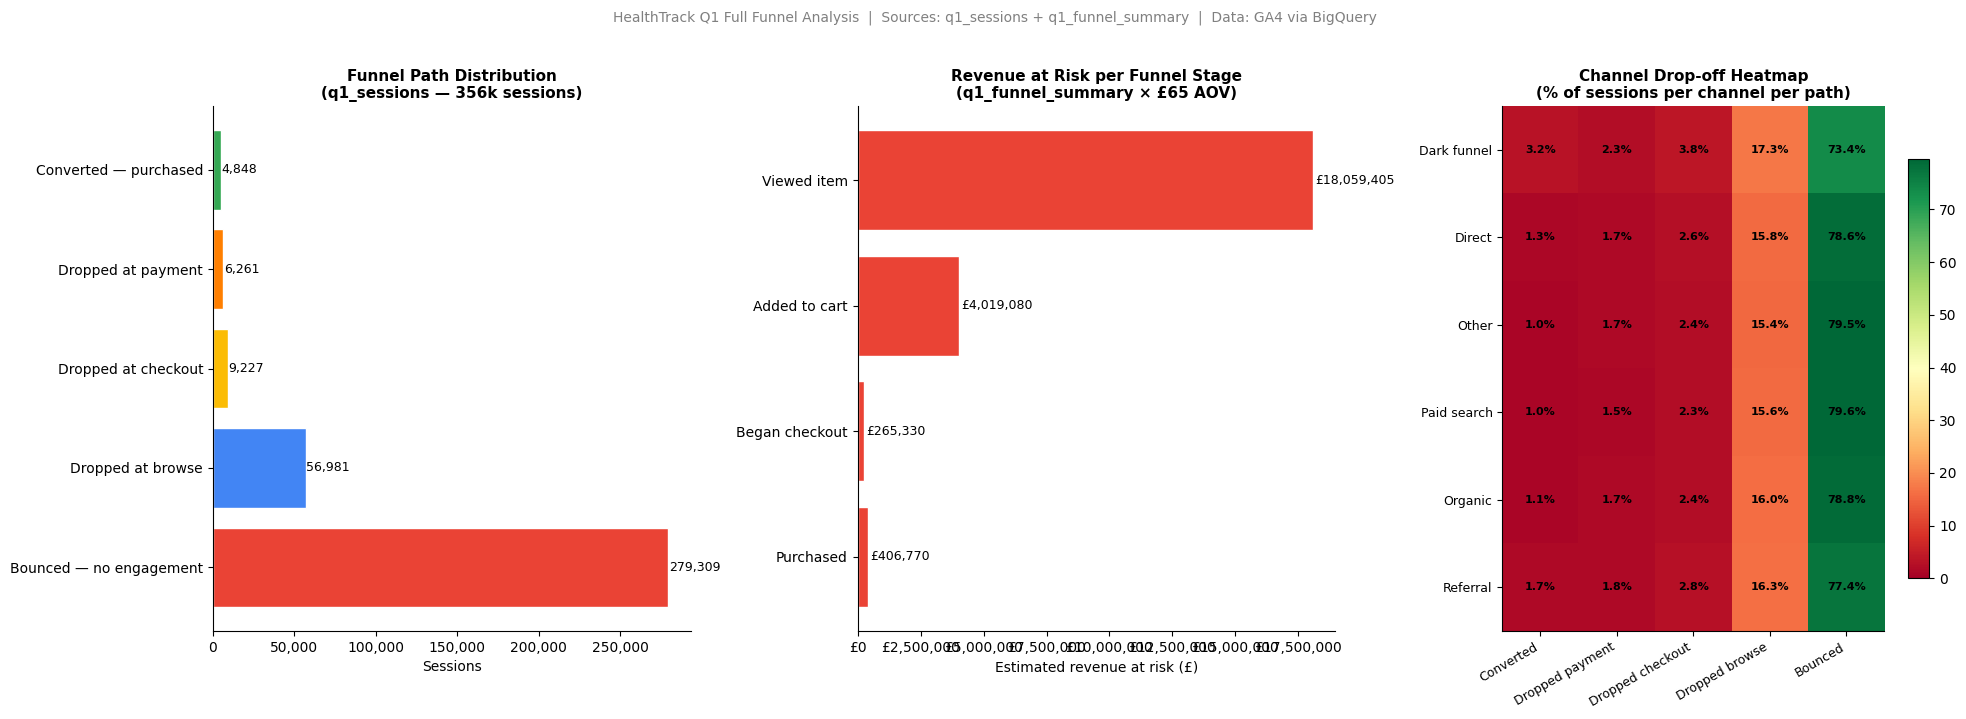

Saved: outputs/figures/05_full_funnel_analysis.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# ── Left: funnel path distribution (from q1_sessions) ─────────
ax1 = axes[0]
colours_path = [GREEN, '#FF7F00', YELLOW, BLUE, RED]
bars = ax1.barh(
    path_dist['label'][::-1],
    path_dist['sessions'][::-1],
    color=colours_path[::-1],
    edgecolor='white'
)
ax1.set_xlabel('Sessions')
ax1.set_title('Funnel Path Distribution\n(q1_sessions — 356k sessions)',
              fontweight='bold', fontsize=11)
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)
for bar, val in zip(bars, path_dist['sessions'][::-1]):
    ax1.text(bar.get_width() + 500,
             bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

# ── Middle: revenue at risk per stage (from q1_funnel_summary) ─
ax2 = axes[1]
df_risk = df_funnel[df_funnel['sessions_lost'] > 0].copy()
bars2 = ax2.barh(
    df_risk['stage'][::-1],
    df_risk['est_revenue_at_risk_gbp'][::-1],
    color=RED, edgecolor='white'
)
ax2.set_xlabel('Estimated revenue at risk (£)')
ax2.set_title('Revenue at Risk per Funnel Stage\n'
              '(q1_funnel_summary × £65 AOV)',
              fontweight='bold', fontsize=11)
ax2.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)
for bar, val in zip(
    bars2, df_risk['est_revenue_at_risk_gbp'][::-1]
):
    ax2.text(bar.get_width() + 100000,
             bar.get_y() + bar.get_height()/2,
             f'£{val:,.0f}', va='center', fontsize=9)

# ── Right: channel drop-off heatmap (from q1_sessions) ────────
ax3 = axes[2]
pivot_plot = pivot.copy()
pivot_plot.index = pivot_plot.index.map({
    'organic':        'Organic',
    '(none)':         'Direct',
    'referral':       'Referral',
    '<Other>':        'Other',
    '(data deleted)': 'Dark funnel',
    'cpc':            'Paid search'
})
col_labels = {
    'bounced':             'Bounced',
    'dropped_at_browse':   'Dropped browse',
    'dropped_at_checkout': 'Dropped checkout',
    'dropped_at_payment':  'Dropped payment',
    'converted':           'Converted'
}
pivot_plot.columns = [
    col_labels.get(c, c) for c in pivot_plot.columns
]

im = ax3.imshow(
    pivot_plot.values,
    cmap='RdYlGn', aspect='auto',
    vmin=0, vmax=pivot_plot.values.max()
)
ax3.set_xticks(range(len(pivot_plot.columns)))
ax3.set_xticklabels(
    pivot_plot.columns, rotation=30, ha='right', fontsize=9
)
ax3.set_yticks(range(len(pivot_plot.index)))
ax3.set_yticklabels(pivot_plot.index, fontsize=9)
ax3.set_title('Channel Drop-off Heatmap\n'
              '(% of sessions per channel per path)',
              fontweight='bold', fontsize=11)

for i in range(len(pivot_plot.index)):
    for j in range(len(pivot_plot.columns)):
        val = pivot_plot.values[i, j]
        ax3.text(j, i, f'{val:.1f}%',
                ha='center', va='center',
                fontsize=8, fontweight='bold',
                color='black')

plt.colorbar(im, ax=ax3, shrink=0.8)

plt.suptitle(
    'HealthTrack Q1 Full Funnel Analysis  |  '
    'Sources: q1_sessions + q1_funnel_summary  |  '
    'Data: GA4 via BigQuery',
    fontsize=10, color='grey', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/figures/05_full_funnel_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/05_full_funnel_analysis.png')

## Full funnel analysis - key findings across all tables

**Data sources used:**
- `q1_sessions` (356,626 rows) — individual session paths
- `q1_funnel_summary` (5 rows) — aggregated stage metrics
- `q1_channel_performance` (6 rows) — channel breakdown

---

### Finding 1 - The funnel is almost entirely a top-of-funnel problem

78.32% of Q1 sessions bounced with zero product engagement.
A further 15.98% viewed a product but dropped immediately after.

Combined: **94.3% of all sessions never reached the add-to-cart stage.**

The business does not have a checkout problem - it has an
engagement problem. Most visitors never get close enough to checkout
for checkout friction to matter.

---

### Finding 2 - Revenue priority order is counterintuitive

| Stage | Revenue at risk | Action priority |
|---|---|---|
| Viewed item (bounce) | £18,059,405 | Fix traffic quality and homepage |
| Added to cart | £4,019,080 | Fix product page conversion |
| Purchased (checkout drop) | £406,770 | Fix payment friction |
| Began checkout | £265,330 | Fix checkout UX |

The largest revenue number is at the top of the funnel -
not at checkout. Most businesses focus on checkout optimisation
because it feels closer to the money. The data says the real
opportunity is upstream.

---

### Finding 3 - Channel drop-off heatmap reveals different failure modes

| Channel | Bounce rate | Converted | Primary failure point |
|---|---|---|---|
| Dark funnel | 73.4% | 3.2% | Checkout drop (3.75%) |
| Referral | 77.4% | 1.7% | Browse drop (16.3%) |
| Organic | 78.8% | 1.1% | Bounce (78.8%) |
| Paid search | 79.6% | 1.0% | Bounce (79.6%) |

Dark funnel has the lowest bounce rate and highest conversion.
Its relatively high checkout drop-off (3.75%) suggests high-intent
visitors hitting genuine payment friction - a very different
problem from the traffic quality issue affecting paid search.

Paid search and organic show nearly identical funnel patterns
despite one being paid and one being free. This questions the
incremental value of paid search spend - tested directly in NB3.

---

### Transition to NB2

The funnel analysis has established:
1. Where revenue is leaking (top of funnel - bounce)
2. Which channels fail at different stages (heatmap)
3. That dark funnel systematically outperforms at every stage

The remaining question: does last-touch attribution correctly
reflect these channel differences or is it misattributing credit?

A paid search session that brings a user in session 1 who then
returns via direct in session 8 to purchase will show as a
direct conversion in last-touch attribution. Paid search gets
zero credit despite initiating the journey.

**NB2 builds a Markov chain attribution model to test whether
redistributing credit across all touchpoints changes the
channel performance ranking and what that means for budget.**